In [1]:
# First Class to import data
class Import:
    
    def __init__(self):
        # importing libaries
        import pandas as pd
        import numpy as np
        
        self.pd = pd
        self.np = np

        # importing files
    def file_path(self, train_path, test_path):
        self.train_data = self.pd.read_csv(train_path)
        self.test_data = self.pd.read_csv(test_path)
        return self

In [2]:
# Object
data = Import()

data1 = data.file_path(r'C:\Users\Ratnajit\Desktop\Team-8-Ratnajit_Chakraborty_IIT Hackatheron\Dataset\Datasets\train.csv', 
                       r'C:\Users\Ratnajit\Desktop\Team-8-Ratnajit_Chakraborty_IIT Hackatheron\Dataset\Datasets\test.csv')
train_df = data1.train_data
test_df = data1.test_data
print(f'Train data\n{train_df.head()}\n')
print(f'Test data\n{test_df.head()}')

Train data
   customer_id      destination  passanger weather  temperature  time  \
0       258868  No Urgent Place  Friend(s)   Sunny           80   6PM   
1       318369             Work      Alone   Sunny           80   7AM   
2       320906  No Urgent Place      Alone   Sunny           80  10AM   
3       412393             Work      Alone   Rainy           55   7AM   
4       290854             Home      Alone   Snowy           30   6PM   

            coupon expiration  gender age  ... CoffeeHouse  CarryAway  \
0  Restaurant(<20)         1d    Male  21  ...         1~3        4~8   
1  Restaurant(<20)         2h    Male  21  ...         1~3        4~8   
2     Coffee House         2h  Female  21  ...         gt8        4~8   
3  Restaurant(<20)         2h  Female  26  ...       less1        4~8   
4     Coffee House         1d    Male  31  ...       less1        4~8   

  RestaurantLessThan20 Restaurant20To50 toCoupon_GEQ5min toCoupon_GEQ15min  \
0                  4~8           

In [3]:
# Second class for data quality check

class DataCleaner_and_Checker:

    def __init__(self, train_data=None, test_data=None):
        self.train_data = train_data.copy() if train_data is not None else train_df.copy()
        self.test_data = test_data.copy() if test_data is not None else test_df.copy()
        self.np = data.np


    def check_counts(self):
        print('Train Shape:', self.train_data.shape)
        print('Test Shape :', self.test_data.shape)

        print('\nTrain Rows:', self.train_data.shape[0])
        print('Train Columns:', self.train_data.shape[1])

        print('\nTest Rows:', self.test_data.shape[0])
        print('Test Columns:', self.test_data.shape[1])

        
    def clean_data(self):

        # remove dups
        self.train_data = self.train_data.drop_duplicates()
        self.test_data = self.test_data.drop_duplicates()

        # replace nan with actual missing vals
        self.train_data = self.train_data.replace('nan', self.np.nan)
        self.test_data = self.test_data.replace('nan', self.np.nan)

        # fill missing vals
        categorical_cols = self.train_data.select_dtypes(include='object').columns

        self.train_data[categorical_cols] = (self.train_data[categorical_cols].fillna('Unknown'))

        self.test_data[categorical_cols] = (self.test_data[categorical_cols].fillna('Unknown'))

        return self

In [4]:
# print clean data
import warnings
warnings.filterwarnings('ignore')

# Object
clean = DataCleaner_and_Checker()

clean.check_counts()

clean.clean_data()

train_df_clean = clean.train_data
test_df_clean = clean.test_data

print(train_df_clean.head())
print(test_df_clean.head())

Train Shape: (10147, 27)
Test Shape : (2537, 26)

Train Rows: 10147
Train Columns: 27

Test Rows: 2537
Test Columns: 26
   customer_id      destination  passanger weather  temperature  time  \
0       258868  No Urgent Place  Friend(s)   Sunny           80   6PM   
1       318369             Work      Alone   Sunny           80   7AM   
2       320906  No Urgent Place      Alone   Sunny           80  10AM   
3       412393             Work      Alone   Rainy           55   7AM   
4       290854             Home      Alone   Snowy           30   6PM   

            coupon expiration  gender age  ... CoffeeHouse  CarryAway  \
0  Restaurant(<20)         1d    Male  21  ...         1~3        4~8   
1  Restaurant(<20)         2h    Male  21  ...         1~3        4~8   
2     Coffee House         2h  Female  21  ...         gt8        4~8   
3  Restaurant(<20)         2h  Female  26  ...       less1        4~8   
4     Coffee House         1d    Male  31  ...       less1        4~8   

  

In [5]:
# Check nulls and duplicates for both train and test
for i in set(train_df_clean.columns) | set(test_df_clean.columns):
    # Only check for nulls if the column actually exists in the respective dataframe
    train_null = train_df_clean[i].isnull().sum() if i in train_df_clean.columns else 0
    test_null = test_df_clean[i].isnull().sum() if i in test_df_clean.columns else 0
    
    if train_null > 0 or test_null > 0:
        print(f'{i} - Train Nulls: {train_null}, Test Nulls: {test_null}')

# Duplicate rows
print('\nDuplicate rows:')
print('Train:', train_df_clean.duplicated().sum())
print('Test :', test_df_clean.duplicated().sum())


Duplicate rows:
Train: 0
Test : 0


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


class EDA_and_plot:

    def __init__(self, train_data=None, test_data=None):
        self.train_data = train_data.copy() if train_data is not None else train_df_clean.copy()
        self.test_data = test_data.copy() if test_data is not None else test_df_clean.copy()

    # Check column information
    def check_columns(self):
        print('Train Columns:')
        print(self.train_data.columns.tolist())

        print('\nTrain Data Types:')
        print(self.train_data.dtypes)

        print('\nNumeric Columns:')
        print(self.train_data.select_dtypes(include='number').columns.tolist())

        print('\nCategorical Columns:')
        print(self.train_data.select_dtypes(include='object').columns.tolist())

    # Histograms
    def histograms(self):
        numeric_cols = self.train_data.select_dtypes(include='number').columns

        for z in numeric_cols:
            plt.figure(figsize=(7, 4))
            sns.histplot(self.train_data[z], kde=True)
            plt.title(f'Distribution of {z}')
            plt.xlabel(z)
            plt.ylabel('Frequency')
            plt.show()

    # Boxplots
    def boxplots(self):
        numeric_cols = self.train_data.select_dtypes(include='number').columns
        for p in numeric_cols:
            plt.figure(figsize=(7, 4))
            sns.boxplot(x=self.train_data[p])
            plt.title(f'Boxplot of {p}')
            plt.xlabel(p)
            plt.show()

   
    # Scatter plots between independent variables and target
    def scatterplots(self):
        numeric_cols = self.train_data.select_dtypes(include='number').columns

        # Remove target from independent variables
        numeric_cols = [i for i in numeric_cols if i != 'Y']

        for z in numeric_cols:
            plt.figure(figsize=(7, 4))
            sns.scatterplot(x=self.train_data[z], y=self.train_data['Y'])
            plt.title(f'{z} vs Y')
            plt.xlabel(z)
            plt.ylabel('Y')
            plt.show()

    # Correlation heatmap
    def correlation(self):
        numeric_data = self.train_data.select_dtypes(include='number')
        plt.figure(figsize=(10, 7))
        sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
        plt.title('Correlation Heatmap')
        plt.show()

Train Columns:
['customer_id', 'destination', 'passanger', 'weather', 'temperature', 'time', 'coupon', 'expiration', 'gender', 'age', 'maritalStatus', 'has_children', 'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Y']

Train Data Types:
customer_id             int64
destination               str
passanger                 str
weather                   str
temperature             int64
time                      str
coupon                    str
expiration                str
gender                    str
age                       str
maritalStatus             str
has_children            int64
education                 str
occupation                str
income                    str
car                       str
Bar                       str
CoffeeHouse               str
CarryAway                 str
RestaurantLessThan2

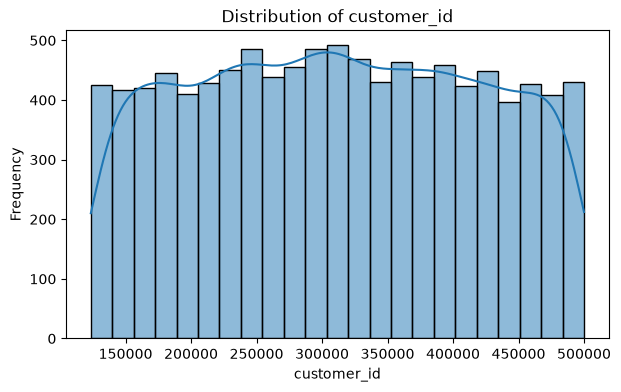

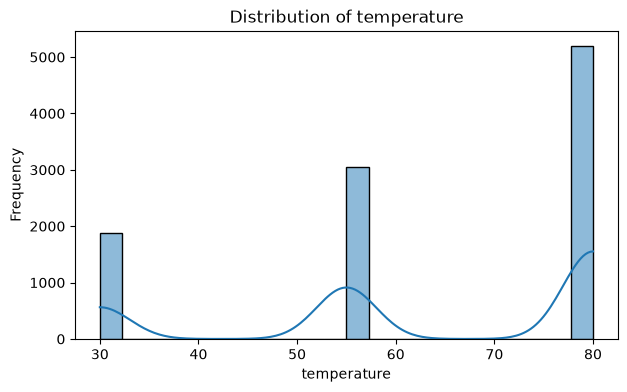

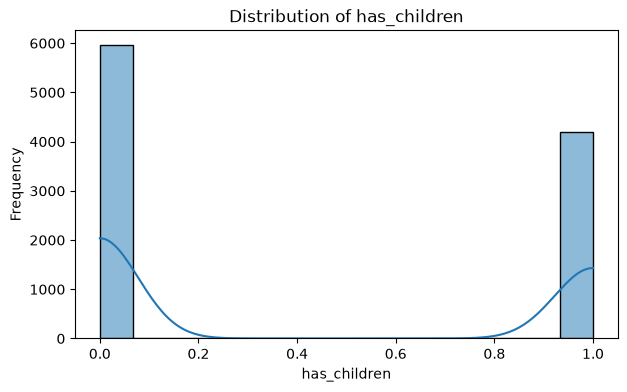

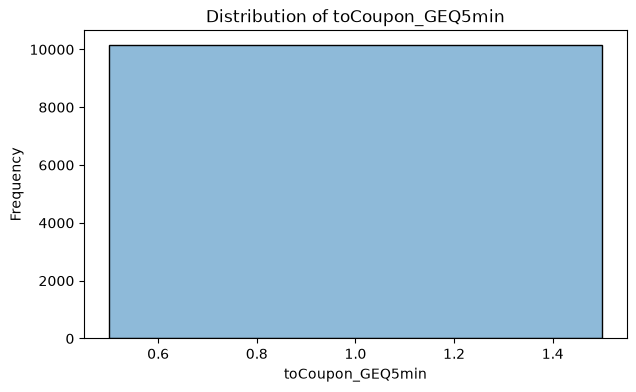

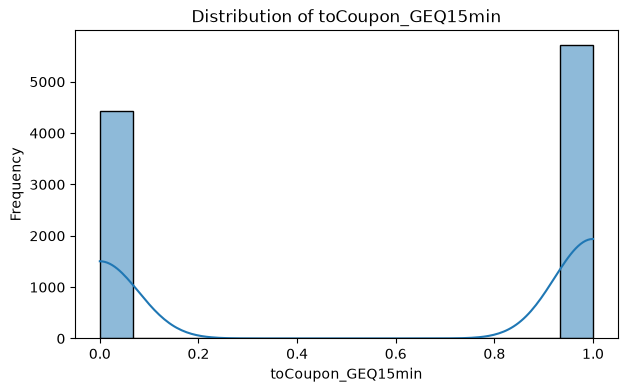

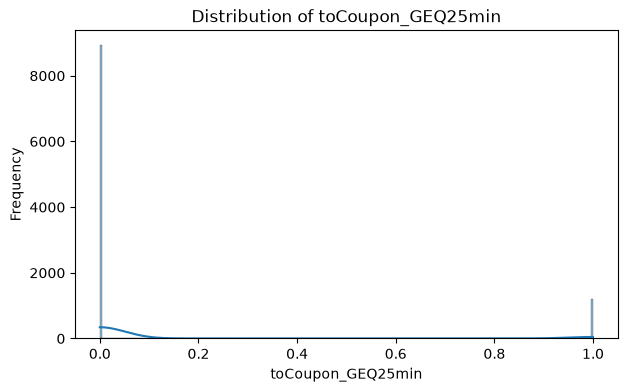

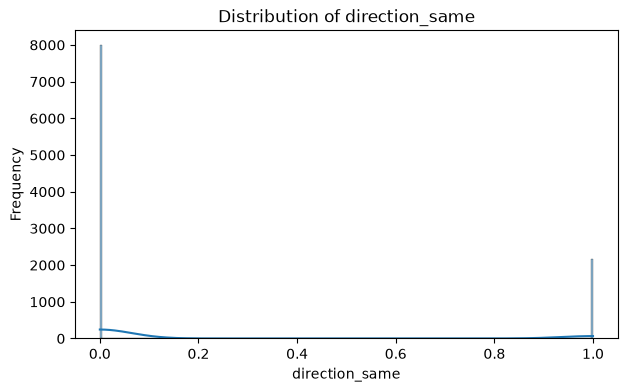

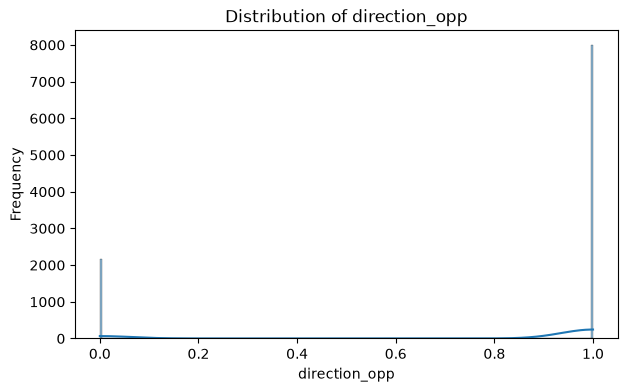

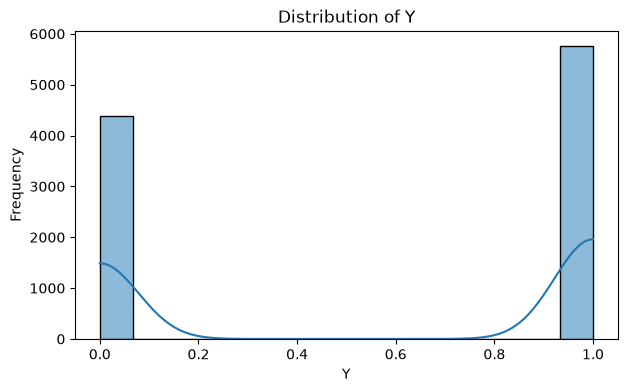

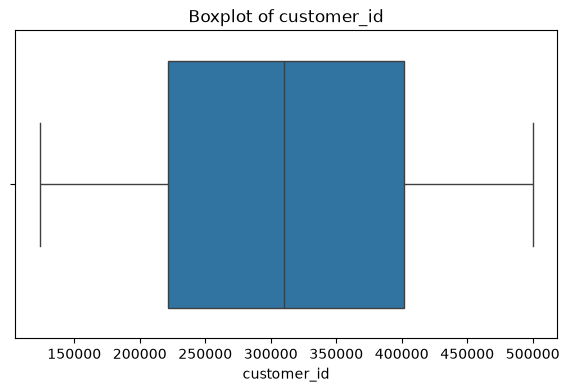

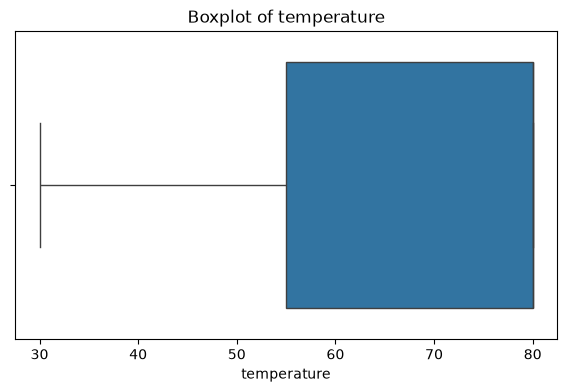

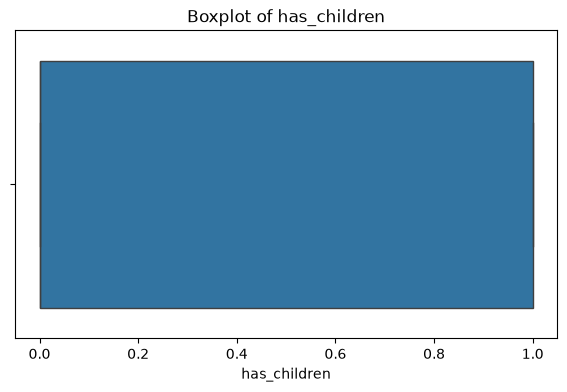

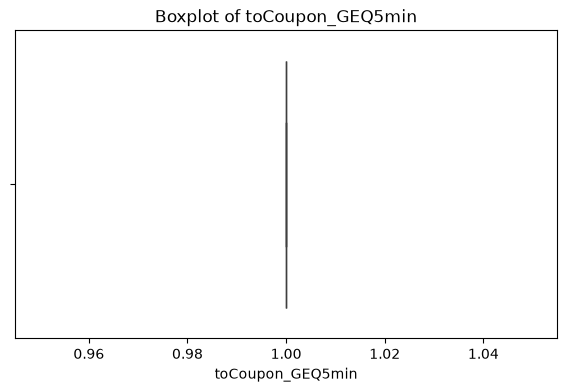

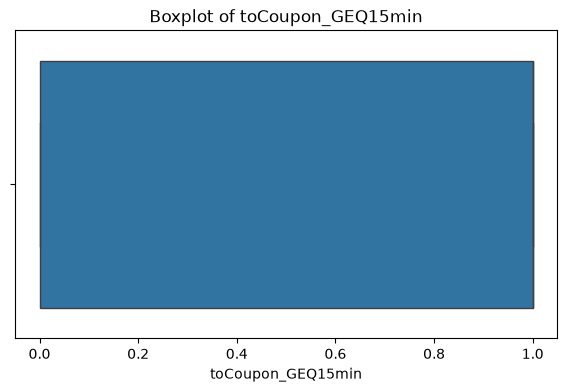

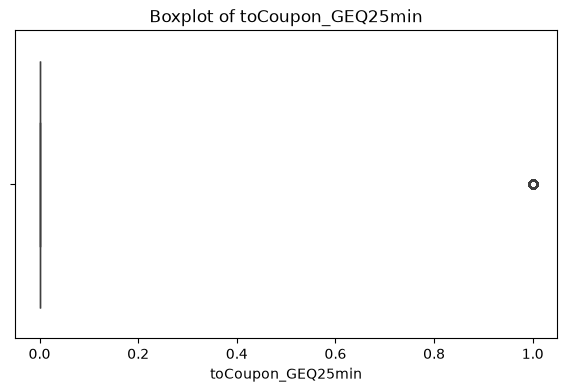

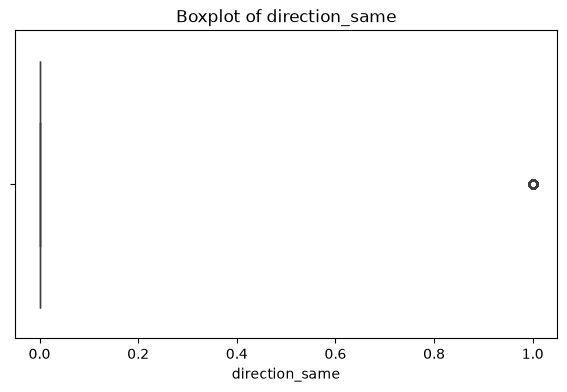

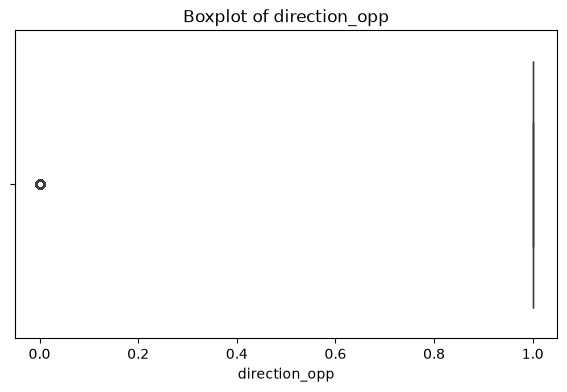

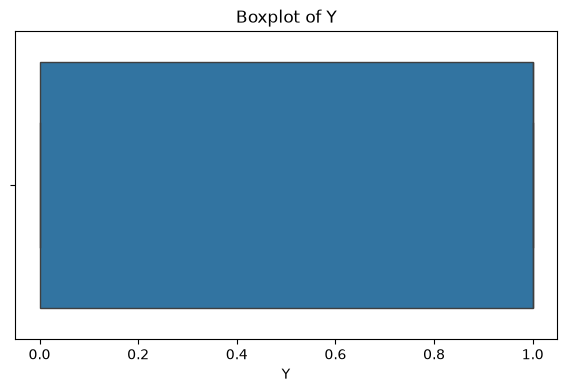

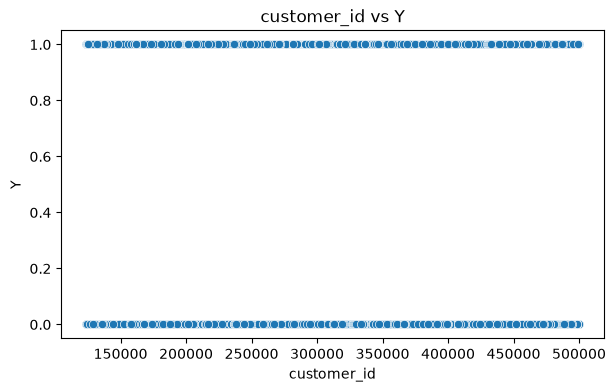

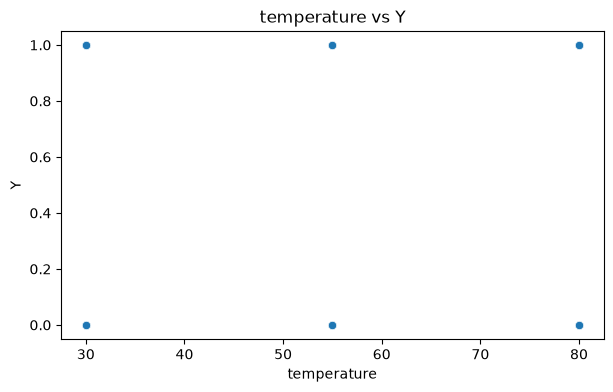

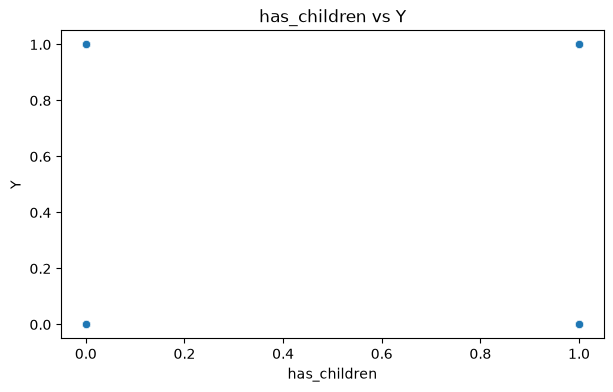

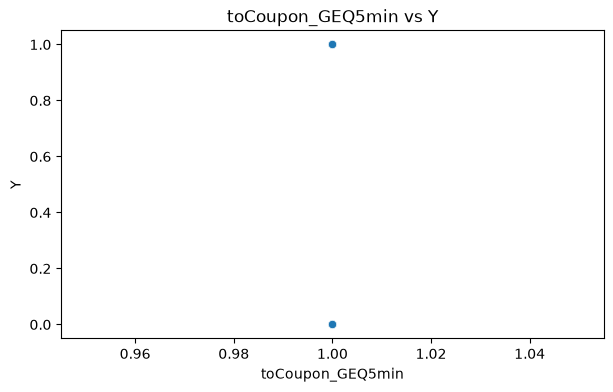

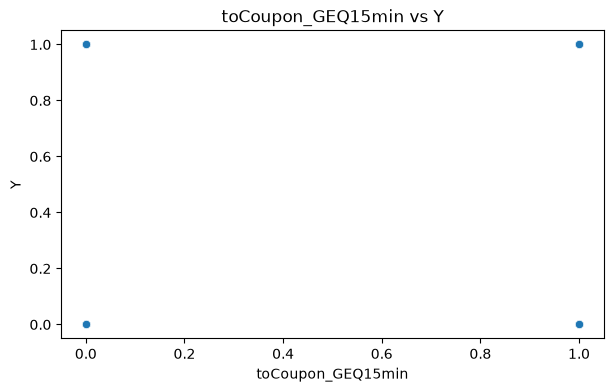

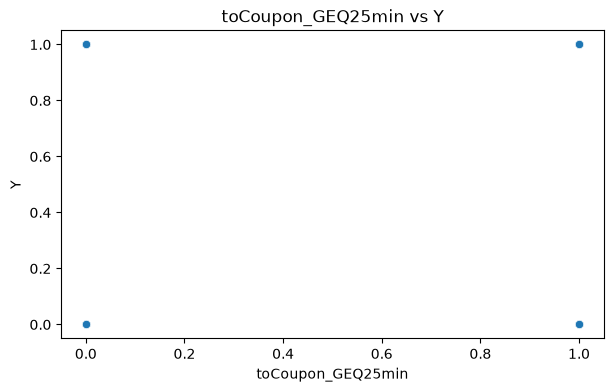

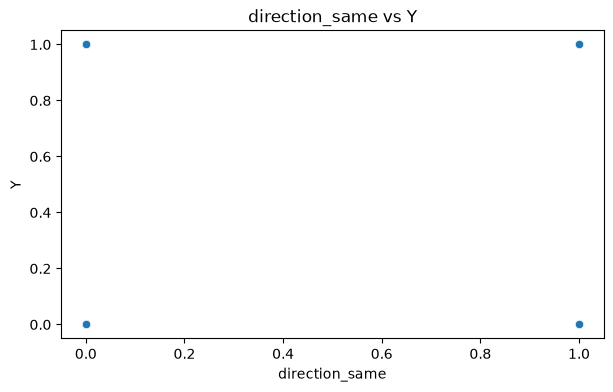

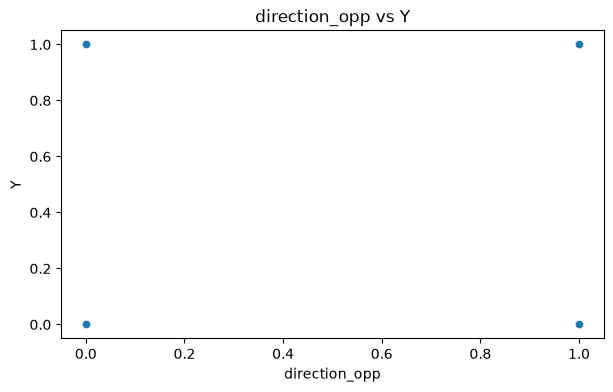

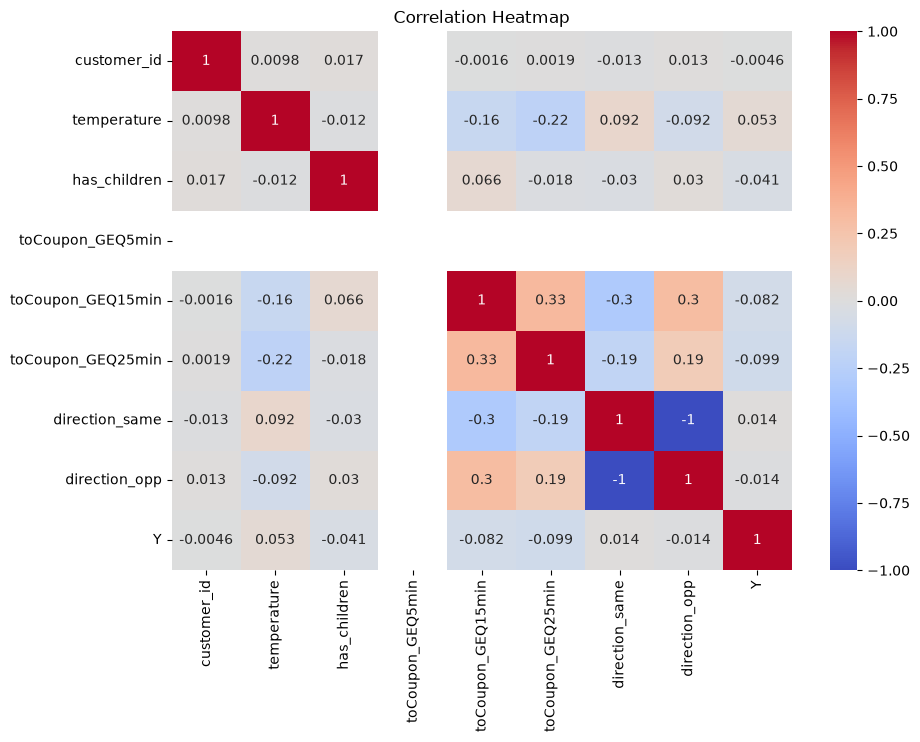

In [7]:
# Object
eda = EDA_and_plot()

eda.check_columns()

eda.histograms()

eda.boxplots()

eda.scatterplots()

eda.correlation()

Key EDA Observations Noted in the Output:   

The dataset contains 10,147 records and 27 columns.   

The temperature variable ranges from 30 to 80, primarily concentrated around higher temperatures (left skewness).   

No duplicate rows were found.

Missing values are mainly in the car column, with a small number also present in Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, and Restaurant20To50.

Boxplot and outlier analysis showed no major issues in the continuous variable temperature. Some binary variables were flagged by the IQR method, but these represent valid 0/1 categories, not data errors.

Correlation analysis and scatter plots indicated that numerical variables have weak linear relationships with the target variable.

Running Hypothesis Test - chi2_contingency

In [8]:
# As I found no strong linear relationship, I will do a chi-square test to check if the categorical variables have any impact on the binary column
# null hypothesis - Category variables not no effect
# Alternative hypothesis - Category variables has effect

from scipy.stats import chi2_contingency
pd = data.pd


categorical_cols = train_df_clean.select_dtypes(include=['object', 'category']).columns

for i in categorical_cols:
    contingency_table = pd.crosstab(train_df_clean[i], train_df_clean['Y'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f'{i}')
    print(f'Chi-square: {chi2:.2f}')
    print(f'p-value: {p_value:.4f}')

destination
Chi-square: 175.25
p-value: 0.0000
passanger
Chi-square: 179.23
p-value: 0.0000
weather
Chi-square: 97.87
p-value: 0.0000
time
Chi-square: 137.19
p-value: 0.0000
coupon
Chi-square: 697.42
p-value: 0.0000
expiration
Chi-square: 179.14
p-value: 0.0000
gender
Chi-square: 17.62
p-value: 0.0000
age
Chi-square: 45.51
p-value: 0.0000
maritalStatus
Chi-square: 33.22
p-value: 0.0000
education
Chi-square: 39.24
p-value: 0.0000
occupation
Chi-square: 95.43
p-value: 0.0000
income
Chi-square: 47.62
p-value: 0.0000
car
Chi-square: 7.40
p-value: 0.1926
Bar
Chi-square: 70.56
p-value: 0.0000
CoffeeHouse
Chi-square: 229.41
p-value: 0.0000
CarryAway
Chi-square: 35.14
p-value: 0.0000
RestaurantLessThan20
Chi-square: 23.92
p-value: 0.0002
Restaurant20To50
Chi-square: 45.81
p-value: 0.0000


Hypothesis Test Observation

As all categorical variables except cars has p value < 0.05 it rejects the null hypothesis, means all categorical variables
has a impact on the target.

Car's p value is 0.1926, which is >= 0.05 it fails to reject the null hypothesis, hence it has no impact on Y.

In [9]:
# Define target and independent variables
X_train = train_df_clean.drop(['Y', 'customer_id', 'car'], axis=1)
y_train = train_df_clean['Y']

X_test = test_df_clean.drop(['customer_id', 'car'], axis=1)

In [10]:
# Encoding categorical variables
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first') # using drop first to remove one of the dummy columns

encoder.fit(X_train)

X_train_encoded = encoder.transform(X_train).astype(float)
X_test_encoded = encoder.transform(X_test).astype(float)

In [11]:
# Training Logistic Regression with 3-fold cross-validation

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) # uaing k fold = 3

# Logistic Regression
log_pipeline = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000))])

log_scores = cross_val_score(log_pipeline, X_train_encoded, y_train,cv=cv, scoring='accuracy')

print('Logistic Regression CV Scores:', log_scores)
print('Logistic Regression Mean CV Accuracy:', log_scores.mean())

Logistic Regression CV Scores: [0.67927875 0.6812537  0.68746304]
Logistic Regression Mean CV Accuracy: 0.6826651607779741


In [12]:
# Training Random Forest with 3-fold cross-validation - Note: I did not scaled the data for Random Forest and XGBoost as featured 
# scaling generally not required for tree based models

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_scores = cross_val_score(rf_model, X_train_encoded, y_train, cv=cv, scoring='accuracy')

print('Random Forest CV Scores:', rf_scores)
print('Random Forest Mean CV Accuracy:', rf_scores.mean())

Random Forest CV Scores: [0.74046704 0.74157303 0.75280899]
Random Forest Mean CV Accuracy: 0.744949687853234


In [13]:
# Training and evaluating XGBoost using 3-fold cross-validation

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=3, shuffle=True,  random_state=42)

xgb_model = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1)

xgb_scores = cross_val_score(xgb_model, X_train_encoded, y_train, cv=cv, scoring='accuracy')

print('XGBoost CV Scores:', xgb_scores)
print('XGBoost Mean CV Accuracy:', xgb_scores.mean())

XGBoost CV Scores: [0.75376884 0.74127735 0.74423418]
XGBoost Mean CV Accuracy: 0.7464267919530632


In [14]:
# XGBoost with Grid Search

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier

# Define the hyperparameter grid
param_dist = {'n_estimators': [100, 200, 300, 500],'learning_rate': [0.01, 0.05, 0.1, 0.2], 'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9, 1.0], 'colsample_bytree': [0.7, 0.8, 0.9, 1.0], 'gamma': [0, 0.1, 0.3, 0.5]}

# Initialize a baseline XGBoost model
xgb_base = XGBClassifier(random_state=42, n_jobs=-1)

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Set up the randomized search using specific CV strategy
random_search = RandomizedSearchCV(estimator=xgb_base, param_distributions=param_dist, n_iter=20,  scoring='accuracy', cv=cv_strategy, verbose=2, 
                                   n_jobs=-1, random_state=42)

random_search.fit(X_train_encoded, y_train)


print(f'\nBest Parameters found: {random_search.best_params_}')
print(f'Best 3-Fold CV Accuracy: {random_search.best_score_}')

best_xgb_model = random_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters found: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.9}
Best 3-Fold CV Accuracy: 0.7631809398915358


# Moving Ahead with XGBoost Model after hyperparameter tuned - It shows the best accuracy score of 76%

In [15]:
# Generate predictions on the test data
y_pred = best_xgb_model.predict(X_test_encoded)

In [16]:
print(y_pred[:20])

[1 1 0 0 1 1 1 0 1 1 0 0 1 1 0 1 0 1 1 0]


In [17]:
# Creating a copy of the test data
test_results = test_df_clean.copy()
test_results['Predicted_Y'] = y_pred

# Display specific columns to use for the prediction
columns_to_view = ['customer_id', 'coupon', 'destination', 'weather', 'time', 'Predicted_Y']
test_results[columns_to_view].head(15)

,customer_id,coupon,destination,weather,time,Predicted_Y
0,374679,Coffee House,No Urgent Place,Sunny,6PM,1
1,469678,Carry out & Take away,Home,Sunny,6PM,1
2,216140,Coffee House,No Urgent Place,Rainy,10AM,0
3,184301,Bar,No Urgent Place,Sunny,6PM,0
4,148720,Carry out & Take away,Work,Sunny,7AM,1
5,145576,Coffee House,Home,Sunny,6PM,1
6,194322,Coffee House,Home,Sunny,6PM,1
7,198210,Coffee House,No Urgent Place,Sunny,10AM,0
8,305477,Restaurant(<20),No Urgent Place,Sunny,10PM,1
9,257384,Carry out & Take away,Work,Sunny,7AM,1


In [18]:
# Create the final submission dataframe with ONLY the required columns
final_submission_Ratnajit_Chakraborty_Team_8 = test_results[['customer_id', 'Predicted_Y']].copy()

# Rename the prediction column to match what the hackathon expects
final_submission_Ratnajit_Chakraborty_Team_8.rename(columns={'Predicted_Y': 'Y'}, inplace=True)

# Export to CSV at the specific desktop folder
final_submission_Ratnajit_Chakraborty_Team_8.to_csv(r'C:\Users\Ratnajit\Desktop\Team-8-Ratnajit_Chakraborty_IIT Hackatheron\final_submission_Ratnajit_Chakraborty_Team_8.csv', index=False)

final_submission_Ratnajit_Chakraborty_Team_8.head(10)

,customer_id,Y
0,374679,1
1,469678,1
2,216140,0
3,184301,0
4,148720,1
5,145576,1
6,194322,1
7,198210,0
8,305477,1
9,257384,1


In [19]:
# Save the model
import joblib

# 1. Save the fitted OneHotEncoder
joblib.dump(encoder, 'encoder.joblib')

# 2. Save the tuned XGBoost model
joblib.dump(best_xgb_model, 'xgb_model.joblib')

print('Model and encoder saved successfully!')

Model and encoder saved successfully!


In [22]:
%%writefile requirements.txt
fastapi
uvicorn
pandas
xgboost
joblib
scikit-learn
pydantic

Writing requirements.txt


In [23]:
%%writefile api.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import pandas as pd
import joblib
import numpy as np

# 1. Initialize the FastAPI app
app = FastAPI(title='Coupon Acceptance Prediction API', version='1.0')

# 2. Load models at startup
encoder = joblib.load('encoder.joblib')
model = joblib.load('xgb_model.joblib')

# 3. Define the Input Data Schema using Pydantic
# This ensures the API only accepts the correct data types
class CustomerData(BaseModel):
    destination: str
    passanger: str
    weather: str
    temperature: int
    time: str
    coupon: str
    expiration: str
    gender: str
    age: str
    maritalStatus: str
    has_children: int
    education: str
    occupation: str
    income: str
    Bar: str
    CoffeeHouse: str
    CarryAway: str
    RestaurantLessThan20: str
    Restaurant20To50: str
    toCoupon_GEQ5min: int
    toCoupon_GEQ15min: int
    toCoupon_GEQ25min: int
    direction_same: int
    direction_opp: int

# 4. Define the Prediction Endpoint
@app.post("/predict")
# Pydantic automatically filters out excluded columns like 'customer_id' and 'car', 
# and the following steps replicate the DataCleaner_and_Checker logic.
def predict_coupon(data: CustomerData):
    try:
        # Convert incoming JSON payload to a pandas DataFrame
        input_data = pd.DataFrame([data.dict()])
        
        # Preprocessing
        input_data = input_data.replace('nan', np.nan)
        cat_cols = input_data.select_dtypes(include=['object', 'category']).columns
        input_data[cat_cols] = input_data[cat_cols].fillna('Unknown')
        
        # Encode and Predict
        X_encoded = encoder.transform(input_data).astype(float)
        prediction = model.predict(X_encoded)
        
        # Return the result as JSON
        return {'prediction': int(prediction[0]),
            'message': 'Accepted' if prediction[0] == 1 else 'Rejected'}
        
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))

# 5. Root endpoint for health check
@app.get('/')
def read_root():
    return {'status': 'API is running. Visit /docs for documentation.'}

Writing api.py
